

# Chapter 6 — Chemical Visualization (v2026)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/IvanReznikov/LangChain4LifeSciencesHealthcare)

**Learning objectives**
- Render RDKit 2D depictions and grids
- Plot descriptor distributions and scaffold counts
- Make similarity/SAR and dose-response plots
- Keep figures provenance-aware (data + source)

> Runtime: ~5 min (local, no API)  
> Cost: free  
> Data: small built-in molecule/assay set

> **LangChain 1.x (2026)** — built on `langchain-core==1.2.30`, `langchain==1.0.0`. See `UPDATE_2026.md`.


## Environment setup


### Secrets (optional LLM only)


In [1]:
# @title Setting environmental variables
import os

# --- Dual-mode secrets: works in Google Colab AND locally (.env / environment) ---
try:
    from google.colab import userdata  # type: ignore

    IN_COLAB = True
except Exception:
    userdata = None
    IN_COLAB = False

if not IN_COLAB:
    # Local run: load variables from a .env file if present (never commit .env!).
    try:
        from dotenv import load_dotenv

        load_dotenv()
    except Exception:
        pass


def get_secret(name, default=None):
    """Read a secret from Colab Secrets, else from local env/.env, else default."""
    if IN_COLAB and userdata is not None:
        try:
            val = userdata.get(name)
            if val:
                return val
        except Exception:
            pass
    return os.getenv(name, default)


# 👇 Choose your provider 👇
API_KEY_PROVIDER = "OPENAI"  # "GEMINI" | "OPENAI" | "GROQ" | "ANTHROPIC"

if API_KEY_PROVIDER == "OPENAI":
    os.environ["OPENAI_API_KEY"] = get_secret("LC4LSH_OPENAI_API_KEY", "sk-...")
elif API_KEY_PROVIDER == "ANTHROPIC":
    os.environ["ANTHROPIC_API_KEY"] = get_secret(
        "LC4LSH_ANTHROPIC_API_KEY", "sk-ant-..."
    )
elif API_KEY_PROVIDER == "GEMINI":
    os.environ["GOOGLE_API_KEY"] = get_secret("LC4LSH_GOOGLE_API_KEY", "AIza...")
elif API_KEY_PROVIDER == "GROQ":
    os.environ["GROQ_API_KEY"] = get_secret("LC4LSH_GROQ_API_KEY", "gsk_...")

print(
    f"✅ API keys loaded for {API_KEY_PROVIDER} (source: {'Colab Secrets' if IN_COLAB else 'local env/.env'})"
)

# Hugging Face token (optional; needed for gated models)
os.environ["HF_TOKEN"] = get_secret("HF_TOKEN", "") or ""

✅ API keys loaded for OPENAI (source: Colab Secrets)


### Install pinned dependencies


In [2]:
# @title Installing Python dependencies
%pip install -q "rdkit" "langchain" "langchain-core" "langchain-openai" "pandas" "matplotlib" "scipy" "numpy<2" python-dotenv
# Pinned versions - Last validated: 2026-07-21 (see UPDATE_2026.md)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.1/122.1 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.7/561.7 kB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 78.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 5.0.0.93 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you

In [3]:
# @title Setting LangSmith variables
LANGSMITH_API_KEY = get_secret("LANGSMITH_API_KEY", "")
LANGSMITH_PROJECT = "lc4lsh-chapter6-chem-viz"
if LANGSMITH_API_KEY and LANGSMITH_API_KEY.startswith(("lsv2_", "ls__")):
    os.environ["LANGSMITH_TRACING"] = "true"
    os.environ["LANGSMITH_API_KEY"] = LANGSMITH_API_KEY
    os.environ["LANGSMITH_PROJECT"] = LANGSMITH_PROJECT
    print("LangSmith ON ->", LANGSMITH_PROJECT)
else:
    os.environ["LANGSMITH_TRACING"] = "false"
    print("LangSmith OFF (fine — these notebooks are local/RDKit-first)")

LangSmith ON -> lc4lsh-chapter6-chem-viz


## Provenance-aware chemical figures

Every figure should be traceable to its source data. These examples use RDKit + matplotlib on a small built-in set; each plot notes its data source.


## 1. 2D depictions and a molecule grid


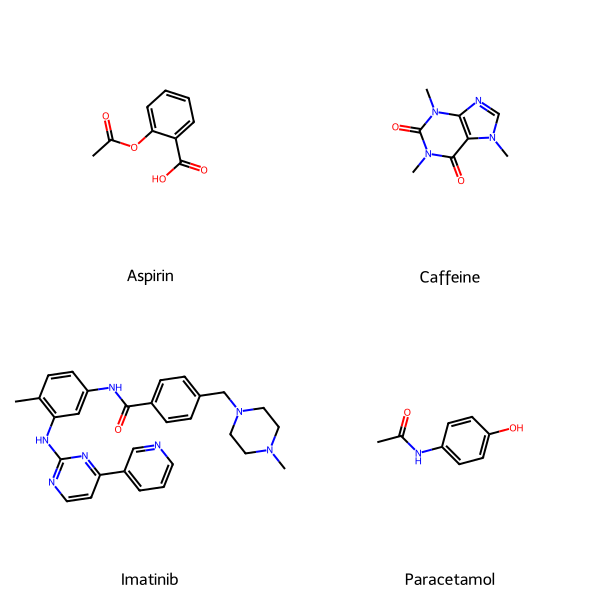

In [4]:
from rdkit import Chem
from rdkit.Chem import Draw

MOLS = {
    "Aspirin": "CC(=O)Oc1ccccc1C(=O)O",
    "Caffeine": "Cn1cnc2c1c(=O)n(C)c(=O)n2C",
    "Imatinib": "Cc1ccc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)cc1Nc1nccc(-c2cccnc2)n1",
    "Paracetamol": "CC(=O)Nc1ccc(O)cc1",
}
mols = [Chem.MolFromSmiles(s) for s in MOLS.values()]
Draw.MolsToGridImage(
    mols, molsPerRow=2, subImgSize=(300, 300), legends=list(MOLS.keys())
)

## 2. Descriptor distributions


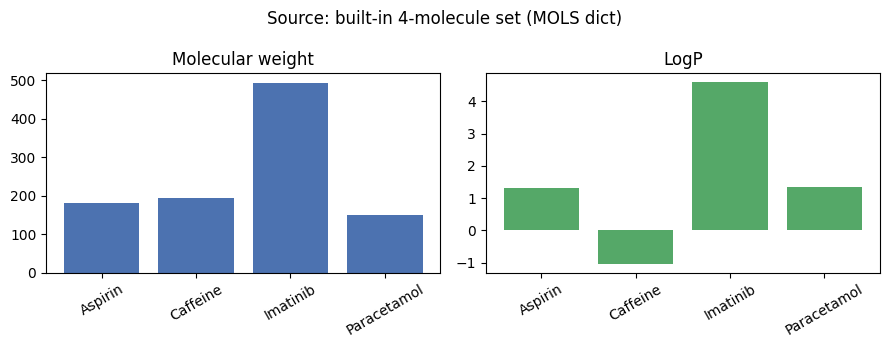

In [5]:
import matplotlib.pyplot as plt
from rdkit.Chem import Descriptors

names = list(MOLS.keys())
mw = [Descriptors.MolWt(m) for m in mols]
logp = [Descriptors.MolLogP(m) for m in mols]

fig, ax = plt.subplots(1, 2, figsize=(9, 3.5))
ax[0].bar(names, mw, color="#4C72B0")
ax[0].set_title("Molecular weight")
ax[0].tick_params(axis="x", rotation=30)
ax[1].bar(names, logp, color="#55A868")
ax[1].set_title("LogP")
ax[1].tick_params(axis="x", rotation=30)
fig.suptitle("Source: built-in 4-molecule set (MOLS dict)")
plt.tight_layout()
plt.show()

## 3. Scaffold counts


In [6]:
from rdkit.Chem.Scaffolds import MurckoScaffold
from collections import Counter

scaffolds = [MurckoScaffold.MurckoScaffoldSmiles(mol=m) for m in mols]
counts = Counter(scaffolds)
print("Bemis-Murcko scaffolds:")
for scaf, n in counts.items():
    print("  " + str(n) + "x  " + (scaf or "(acyclic)"))

Bemis-Murcko scaffolds:
  2x  c1ccccc1
  1x  O=c1[nH]c(=O)c2[nH]cnc2[nH]1
  1x  O=C(Nc1cccc(Nc2nccc(-c3cccnc3)n2)c1)c1ccc(CN2CCNCC2)cc1


## 4. Similarity / SAR heatmap


[13:54:22] DEPRECATION WARNING: please use MorganGenerator
[13:54:22] DEPRECATION WARNING: please use MorganGenerator
[13:54:22] DEPRECATION WARNING: please use MorganGenerator
[13:54:22] DEPRECATION WARNING: please use MorganGenerator


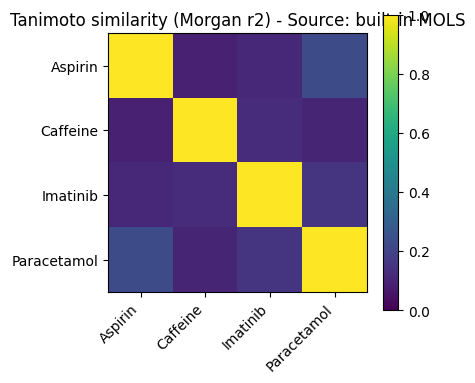

In [7]:
import numpy as np
from rdkit import DataStructs
from rdkit.Chem import AllChem

fps = [AllChem.GetMorganFingerprintAsBitVect(m, 2, nBits=1024) for m in mols]
n = len(mols)
sim = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        sim[i, j] = DataStructs.TanimotoSimilarity(fps[i], fps[j])

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(sim, cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(n))
ax.set_xticklabels(names, rotation=45, ha="right")
ax.set_yticks(range(n))
ax.set_yticklabels(names)
ax.set_title("Tanimoto similarity (Morgan r2) - Source: built-in MOLS")
fig.colorbar(im)
plt.tight_layout()
plt.show()

## 5. Dose-response curve from supplied data


In [8]:
!pip install -q --ignore-installed numpy==2.0.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 43.6 MB/s eta 0:00:00


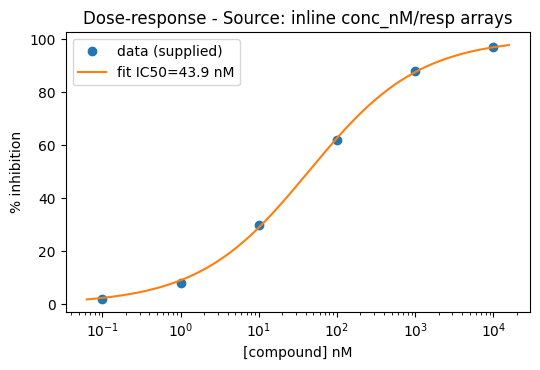

Fitted IC50 = 43.86 nM


In [9]:
from scipy.optimize import curve_fit

conc_nM = np.array([0.1, 1, 10, 100, 1000, 10000])
resp = np.array([2, 8, 30, 62, 88, 97])  # % inhibition, supplied


def hill(x, top, ic50, h):
    return top / (1 + (ic50 / x) ** h)


popt, _ = curve_fit(hill, conc_nM, resp, p0=[100, 50, 1], maxfev=5000)
x = np.logspace(-1.2, 4.2, 200)
plt.figure(figsize=(5.5, 3.8))
plt.semilogx(conc_nM, resp, "o", label="data (supplied)")
plt.semilogx(x, hill(x, *popt), "-", label="fit IC50=" + format(popt[1], ".1f") + " nM")
plt.xlabel("[compound] nM")
plt.ylabel("% inhibition")
plt.title("Dose-response - Source: inline conc_nM/resp arrays")
plt.legend()
plt.tight_layout()
plt.show()
print("Fitted IC50 =", round(float(popt[1]), 2), "nM")

## Limitations & safety notes

- Descriptors (MW/LogP) do NOT establish bioactivity, toxicity, or drug-likeness.
- Similarity (Tanimoto/Morgan) is one of many metrics; scaffold hopping defeats it.
- Dose-response fit quality depends on point spacing/replicates — report replicates and uncertainty.
- Local/free; no API needed.


In [10]:
# Cleanup
import gc

for _v in ("mol", "mols", "df", "llm", "model", "img", "raw", "curated"):
    globals().pop(_v, None)
try:
    import torch

    torch.cuda.empty_cache()
except Exception:
    pass
gc.collect()
print("Cleanup complete.")

Cleanup complete.


## Exercises

<details><summary>Why show the data source on each figure?</summary>Provenance lets a reader trace the figure back to the exact molecules/assay values used.</details>

<details><summary>Why is high Tanimoto similarity not proof of same activity?</summary>Similar structures can have very different activity (activity cliffs); similarity is a heuristic.</details>

<details><summary>Why report replicates for a dose-response fit?</summary>A fit from single points hides variance; replicates give confidence in the IC50 estimate.</details>

### Tasks
- **Task A** - Add a `source` label argument to one plot helper and require it.
- **Task B** - Export the similarity matrix to CSV alongside the heatmap.
- **Task C** - Add error bars to the dose-response from replicate measurements.
- **Task D** - Save each figure as both PNG and an interactive HTML (plotly) with a JSON metadata sidecar.
